# HW2 Task 1: Potential Problems in Linear Regression

This notebook uses synthetic data and generative AI-assisted code to explore three common issues in linear regression: non-linearity, non-constant variance (heteroscedasticity), and collinearity.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

np.random.seed(42)

## Issue 1: Non-linearity

**Explanation:** This issue arises when we use a linear regression model for data that does not actually have a linear relationship. The result is biased coefficient estimates and systematic prediction errors, meaning the model will consistently over- or under-predict in certain ranges of X. The best way to detect this is by looking at residual plots (residuals vs. the predictor $x_i$ or the fitted values $\hat{y}_i$). A good linear fit produces residuals with no discernible pattern whereas a visible curve or trend in the residuals signals non-linearity. This can be addressed by applying non-linear transformations to the predictors.

**Question I investigated:** I did not understand how transforming a predictor would actually fix a non-linear relationship. After some googling, the most helpful explaination I found was that transformations like $\log(X)$, $\sqrt{X}$, or $X^2$ re-express the predictor so that the *transformed* relationship with $Y$ is approximately linear. So rather than changing the model structure, they are reshaping the input so the linearity assumption holds. It follows then that the right transformation depends on the shape of the relationship in the data (e.g., $\log(X)$ works well when the response grows quickly at first then levels off).

In [2]:
# --- Synthetic data ---
n = 200
X = np.linspace(0, 10, n)
y = 0.5 * X**2 - 3 * X + np.random.normal(0, 3, n)  # quadratic with noise

X_reshape = X.reshape(-1, 1)
lin_model = LinearRegression().fit(X_reshape, y)
y_pred = lin_model.predict(X_reshape)
residuals = y - y_pred

# --- Polynomial fix ---
X_sq = np.column_stack([X, X**2])
poly_model = LinearRegression().fit(X_sq, y)
y_pred_poly = poly_model.predict(X_sq)
residuals_poly = y - y_pred_poly

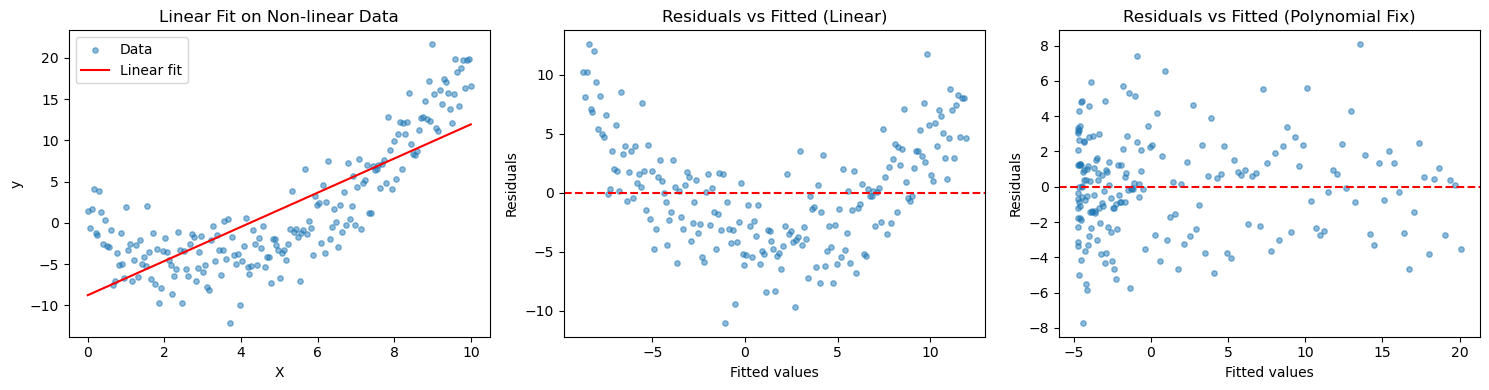

In [3]:
# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Data + linear fit (looks plausible)
axes[0].scatter(X, y, alpha=0.5, s=15, label='Data')
axes[0].plot(X, y_pred, color='red', label='Linear fit')
axes[0].set_title('Linear Fit on Non-linear Data')
axes[0].set_xlabel('X')
axes[0].set_ylabel('y')
axes[0].legend()

# Plot 2: Residuals vs fitted — clear U-shape
axes[1].scatter(y_pred, residuals, alpha=0.5, s=15)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuals vs Fitted (Linear)')
axes[1].set_xlabel('Fitted values')
axes[1].set_ylabel('Residuals')

# Plot 3: Residuals after X^2 term added
axes[2].scatter(y_pred_poly, residuals_poly, alpha=0.5, s=15)
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title('Residuals vs Fitted (Polynomial Fix)')
axes[2].set_xlabel('Fitted values')
axes[2].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

**Figure caption:** The left plot shows some data fit with a linear model where the noise and overall trend make the shape of the data look like it's being reasonably approximated by the line. The middle residual plot reveals that this is actually not the case, since it exhibits a clear U-shaped pattern. This shape indicates that the model is underpredicting at the extremes and overpredicting in the middle. The right plot shows that adding an $X^2$ transformation to the model helps significantly in addressing this pattern, producing residuals that are much more randomly scattered around zero.

---
## Issue 2: Non-constant Variance (Heteroscedasticity)

**Explanation:** Linear regression assumes homoscedasticity, meaning the variance of the error terms is constant across all values of X. Heteroscedasticity is when this assumption is violated, which happens any time the spread of errors grows or shrinks as the fitted values increase. This matters because the assumption underpins all the useful outputs of the regression (standard errors, confidence intervals, p-values), so when it is violated those metrics can't be trusted. This issue can be identified in the residual plot by a funnel or cone shape in the spread of residuals. One solution is to apply a log or square root transformation to the response variable.

**Question I investigated:** I did not understand why a log or square root transformation would help in this particular case. It turns out that it's useful here because it compresses large values more than small ones. When variance is approximately proportional to the mean (a common pattern), multiplicative changes in $Y$ become equal additive changes in $\log(Y)$, which stabilizes the spread of the residuals across the range of fitted values.

In [4]:
# --- Synthetic data ---
n = 200
X = np.linspace(1, 10, n)
y = 2 * X + np.random.normal(0, 0.8 * X**1.3, n)  # variance grows aggressively with X

# ensure y is positive for log transform
y = np.abs(y) + 0.1

X_reshape = X.reshape(-1, 1)
lin_model = LinearRegression().fit(X_reshape, y)
y_pred = lin_model.predict(X_reshape)
residuals = y - y_pred

# --- Log transform fix ---
y_log = np.log(y)
log_model = LinearRegression().fit(X_reshape, y_log)
y_pred_log = log_model.predict(X_reshape)
residuals_log = y_log - y_pred_log

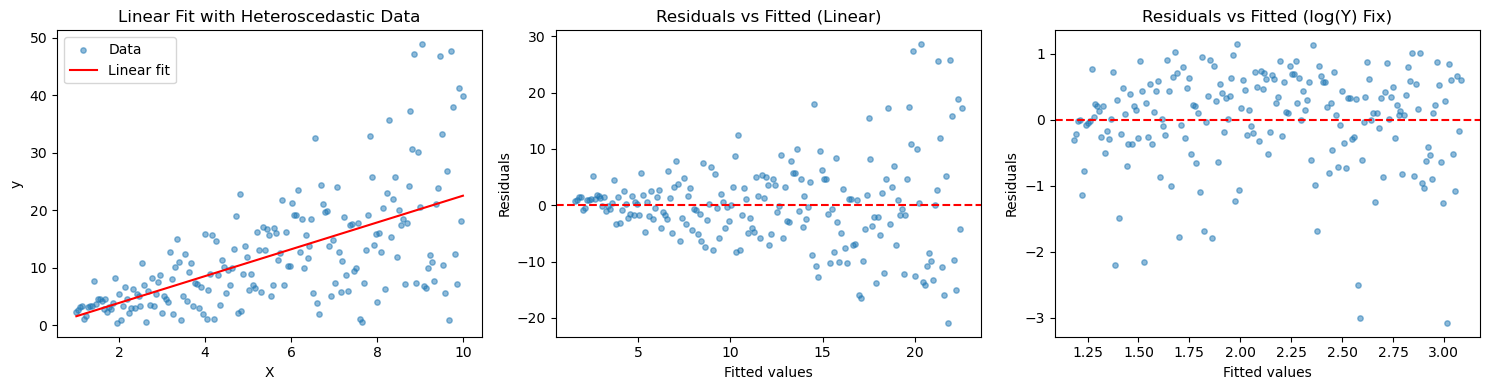

In [5]:
# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Scatter + linear fit — funnel visible in raw data
axes[0].scatter(X, y, alpha=0.5, s=15, label='Data')
axes[0].plot(X, y_pred, color='red', label='Linear fit')
axes[0].set_title('Linear Fit with Heteroscedastic Data')
axes[0].set_xlabel('X')
axes[0].set_ylabel('y')
axes[0].legend()

# Plot 2: Residuals vs fitted — clear funnel shape
axes[1].scatter(y_pred, residuals, alpha=0.5, s=15)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuals vs Fitted (Linear)')
axes[1].set_xlabel('Fitted values')
axes[1].set_ylabel('Residuals')

# Plot 3: Residuals after log(Y) — funnel gone
axes[2].scatter(y_pred_log, residuals_log, alpha=0.5, s=15)
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title('Residuals vs Fitted (log(Y) Fix)')
axes[2].set_xlabel('Fitted values')
axes[2].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

**Figure caption:** The left most plot shows a linear model fit to data whose variance increases with X, in the plot this shows up as the scatter widening as X increases. In the middle residual plot we see a clear funnel shape produced by this increasing variance. The right plot demonstrates how applying a $\log(Y)$ transformation makes the spread of the residuals with much more consistent across the range of fitted values.

---
## Issue 3: Collinearity

**Explanation:** Collinearity is what happens when two or more perdictors are very closely related in some way. It causes issues because it hinders our ability to isolate the individual effects of each predictor on the response. The result is that the standard errors of the affected coefficients become exaggerated which in turn reduces the power of the hypothesis tests making important signals appear statistically insignificant. One simple way to catch this is to look at the correlation matrix (though this misses cases where more than two variables are collinear), a more robust method is to compute the variance inflation factor (VIF) of each $\hat{\beta}_j$. The VIF is the ratio between the variance of a coefficient when fitting the full model divided by the variance if fit on its own so the smallest possible value is 1, no collinearity, and a value > 5 or 10 indicates a more substantial amount of collinearity. The solution is to either drop the collinear variables or combine them into one predictor.

**Question I investigated:** I did not understand what a correlation matrix was when reading this. I have since found out that for a dataset with $p$ predictors $X_1, X_2, \dots, X_p$, the correlation matrix $\mathbf{R}$ is a $p \times p$ matrix where each entry $r_{ij}$ is the Pearson correlation coefficient between predictors $X_i$ and $X_j$:

$$r_{ij} = \frac{\sum_{k=1}^{n}(X_{ik} - \bar{X}_i)(X_{jk} - \bar{X}_j)}{\sqrt{\sum_{k=1}^{n}(X_{ik} - \bar{X}_i)^2 \sum_{k=1}^{n}(X_{jk} - \bar{X}_j)^2}}$$

The diagonal entries are always 1 (a variable is perfectly correlated with itself), and off-diagonal entries range from $-1$ to $1$. Values close to $\pm 1$ indicate collinearity between that pair of predictors. In practice it is visualized as a heatmap, making it easy to spot highly correlated pairs at a glance.

In [6]:
# --- Synthetic data ---
n = 100
X1 = np.random.normal(0, 1, n)
X2 = X1 + np.random.normal(0, 0.15, n)        # highly collinear with X1 (r ~ 0.99)
X3 = 0.5 * X1 + np.random.normal(0, 1, n)     # moderately correlated with X1
X4 = np.random.normal(0, 1, n)                 # independent
y = 2 * X1 + 3 * X4 + np.random.normal(0, 1, n)

df = pd.DataFrame({'X1': X1, 'X2': X2, 'X3': X3, 'X4': X4})

# --- VIF ---
vif_data = pd.DataFrame()
vif_data['Predictor'] = df.columns
vif_data['VIF'] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]

# --- Models ---
X_full = sm.add_constant(df)
X_reduced = sm.add_constant(df[['X1', 'X3', 'X4']])
model_full = sm.OLS(y, X_full).fit()
model_reduced = sm.OLS(y, X_reduced).fit()

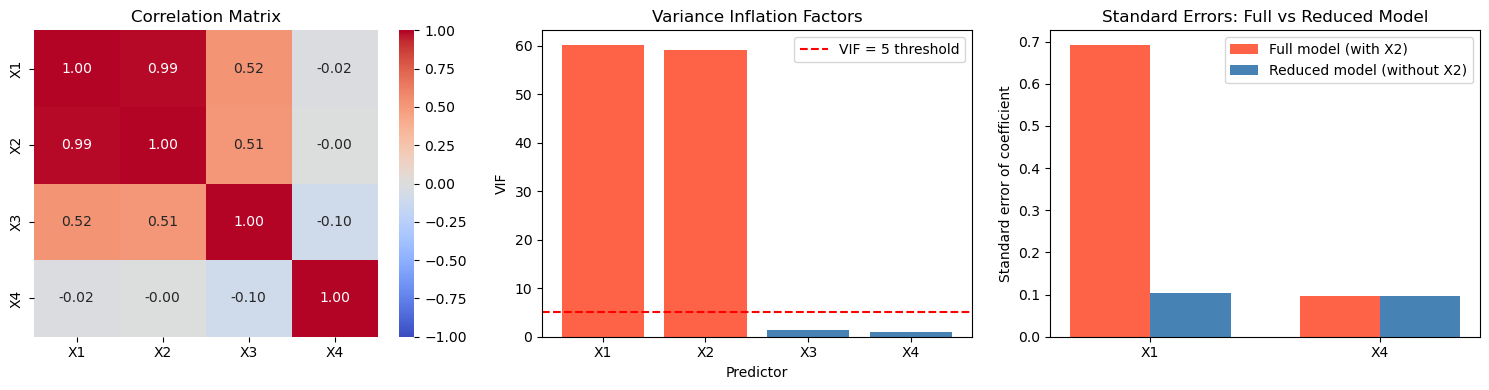

In [7]:
# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Correlation matrix — now more interesting
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Correlation Matrix')

# Plot 2: VIF
colors = ['tomato' if v > 5 else 'steelblue' for v in vif_data['VIF']]
axes[1].bar(vif_data['Predictor'], vif_data['VIF'], color=colors)
axes[1].axhline(5, color='red', linestyle='--', label='VIF = 5 threshold')
axes[1].set_title('Variance Inflation Factors')
axes[1].set_xlabel('Predictor')
axes[1].set_ylabel('VIF')
axes[1].legend()

# Plot 3: Standard errors
predictors = ['X1', 'X4']
full_se = [model_full.bse[p] for p in predictors]
red_se = [model_reduced.bse[p] for p in predictors]

x = np.arange(len(predictors))
width = 0.35
axes[2].bar(x - width/2, full_se, width, color='tomato', label='Full model (with X2)')
axes[2].bar(x + width/2, red_se, width, color='steelblue', label='Reduced model (without X2)')
axes[2].set_xticks(x)
axes[2].set_xticklabels(predictors)
axes[2].set_title('Standard Errors: Full vs Reduced Model')
axes[2].set_ylabel('Standard error of coefficient')
axes[2].legend()

plt.tight_layout()
plt.show()

**Figure caption:** The first plot shows the correlation matrix across four predictors. The darker the value the stronger the correlation, so we can see that X1 and X2 are strongly correlated, X3 is slightly correlated with X1 and X2 and X4 is essentially independent from the other predictors. The second plot shows the VIF values, X1 and X2 have values ~50 which is well above the most common thresholds (5 and 10) while X3 and X4 have values closer to 2. The right plot shows the result of droping X2, we see the standard error for X1 drops significantly and X4's standard error is hardly affected, which confirms that the collinearity between X1 and X2 was the issue.

---
## Generative AI Reflection

I used Claude for the synthetic data and plotting code in this assignment. For each issue I gave it a prompt describing what the synthetic data needed to demonstrate and what I wanted the plots to show. Each time, the first iterations were technically correct but the plots didn't visually demonstrate each issue as clearly as I wanted. For example, the non-linearity code initially used a sine wave which made the scatter plot and residual plot look nearly identical, and the first collinearity correlation matrix only had three predictors with two near-identical values which felt too clean to be realistic. Each section took around 2 to 3 iterations of follow-up prompts describing what was not working before the plots were doing what I needed them to do.